Converged to tolerance 1e-05 in 22 iterations.


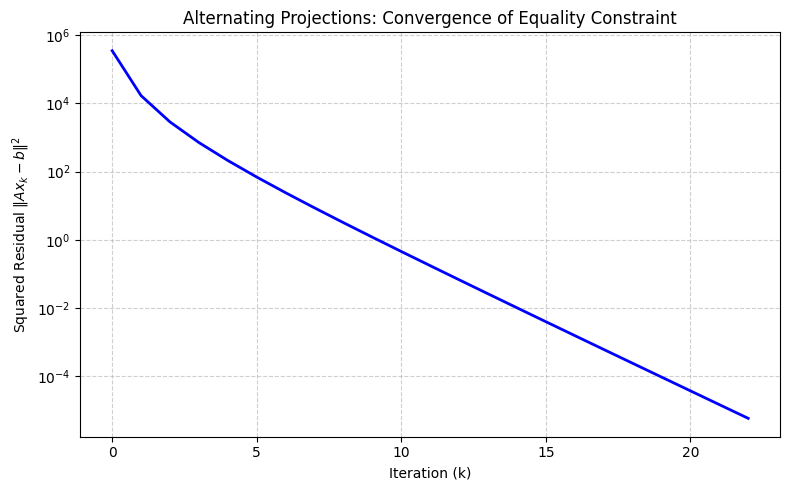

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def solve_alternating_projections(m, n, tol=1e-5, max_iter=10000):
    np.random.seed(42)
    A = np.random.randn(m, n)
    
    x_true = np.random.rand(n) 
    b = A @ x_true
    
    A_pinv = np.linalg.pinv(A) 
    
    x = np.zeros(n)
    sq_residuals = []
    
    for k in range(max_iter):
        res = A @ x - b
        sq_res_norm = np.linalg.norm(res)**2
        sq_residuals.append(sq_res_norm)
        
        if sq_res_norm < tol:
            print(f"Converged to tolerance {tol} in {k} iterations.")
            break
            
        # P_1(x) = x + A^T(AA^T)^{-1}(b - Ax) = x - A_pinv @ res
        y = x - A_pinv @ res
        
        # P_2(x) = max{x, 0}
        x = np.maximum(y, 0)
        
    return sq_residuals

m_dim = 500
n_dim = 2000

residuals = solve_alternating_projections(m_dim, n_dim)

plt.figure(figsize=(8, 5))
plt.plot(residuals, color='blue', linewidth=2)
plt.yscale('log')
plt.xlabel('Iteration (k)')
plt.ylabel(r'Squared Residual $\|Ax_k - b\|^2$')
plt.title('Alternating Projections: Convergence of Equality Constraint')
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

<>:51: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:51: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
C:\Users\aarus\AppData\Local\Temp\ipykernel_36328\664609022.py:51: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  plt.title('Effect of Over-projection Factor $\gamma$ on Convergence')


Gamma 1.0: Converged in 22 iterations.
Gamma 1.3: Converged in 10 iterations.
Gamma 1.6: Converged in 23 iterations.
Gamma 1.9: Converged in 109 iterations.


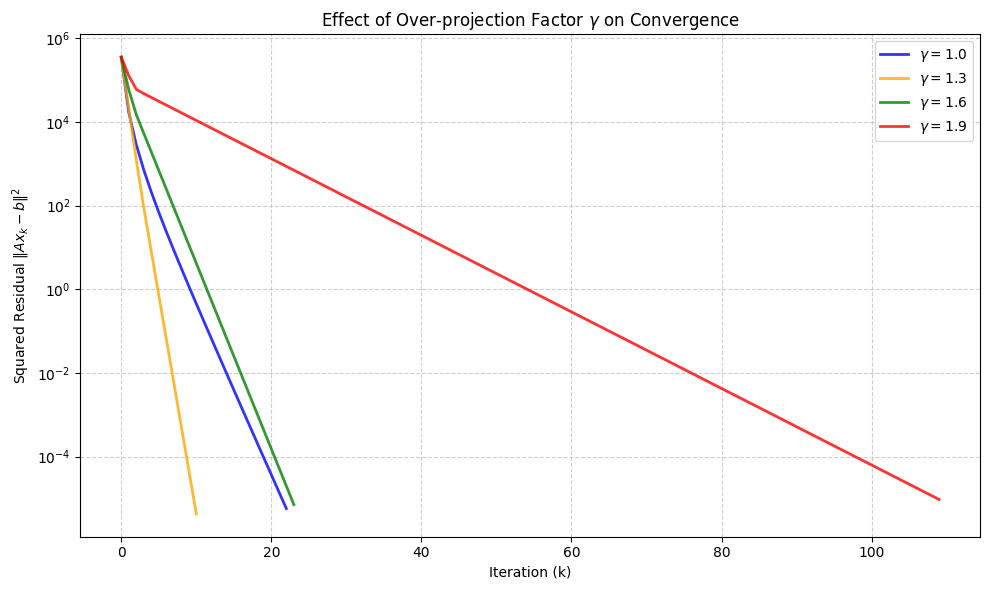

In [3]:
def experiment_overprojection(m, n, gammas, tol=1e-5, max_iter=5000):
    # 1. Setup problem instance
    np.random.seed(42)
    A = np.random.randn(m, n)
    x_true = np.random.rand(n) 
    b = A @ x_true
    
    A_pinv = np.linalg.pinv(A) 
    
    results = {}

    for gamma in gammas:
        x = np.zeros(n)
        sq_residuals = []
        
        for k in range(max_iter):
            res = A @ x - b
            sq_res_norm = np.linalg.norm(res)**2
            sq_residuals.append(sq_res_norm)
            
            if sq_res_norm < tol:
                print(f"Gamma {gamma:.1f}: Converged in {k} iterations.")
                break
                
            # y = x + gamma * (P_1(x) - x)
            y = x - gamma * (A_pinv @ res)
            
            # x_next = y + gamma * (P_2(y) - y)
            p2_y = np.maximum(y, 0)
            x = y + gamma * (p2_y - y)
            
        results[gamma] = sq_residuals
        
    return results

m_dim = 500
n_dim = 2000
gamma_values = [1.0, 1.3, 1.6, 1.9]

results = experiment_overprojection(m_dim, n_dim, gamma_values)

plt.figure(figsize=(10, 6))
colors = ['blue', 'orange', 'green', 'red']

for (gamma, residuals), color in zip(results.items(), colors):
    plt.plot(residuals, label=rf'$\gamma = {gamma}$', color=color, linewidth=2, alpha=0.8)

plt.yscale('log')
plt.xlabel('Iteration (k)')
plt.ylabel(r'Squared Residual $\|Ax_k - b\|^2$')
plt.title('Effect of Over-projection Factor $\gamma$ on Convergence')
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()